In [1]:
import numpy as np
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
import seaborn as sns

## Parámetros del sistema y configuración de simulación

In [2]:
# Áreas de la sección transversal de los tanques [cm^2]
A1, A3 = 28.0, 28.0
A2, A4 = 32.0, 32.0

# Áreas de los orificios de salida [cm^2]
a1, a3 = 0.071, 0.071
a2, a4 = 0.057, 0.057

# Constantes de flujo de las bombas [cm^3/Vs]
k1, k2 = 3.14, 3.29

# Parámetros de división de flujo entre tanques superiores e inferiores
gamma1, gamma2 = 0.43, 0.34

# Aceleración de la gravedad constante [cm/s^2]
g = 981.0

# Configuración del tiempo y paso de integración
dt = 0.05
T_sim = 5000
t = np.arange(0, T_sim + dt, dt)
n = len(t)

# Condiciones iniciales para los niveles de los cuatro tanques [cm]
h0 = np.array([12.6, 13.0, 4.8, 4.9])

# Desviación estándar del ruido gaussiano para entradas y salidas
noise_input_std = 0.1
noise_output_std = 0.1

# Duración de los escalones para la señal de excitación
t_cambio_min = 50
t_cambio_max = 50

# Límites de operación de voltaje para las bombas de agua
V_min = 0.0
V_max = 6.0

## Función del sistema dinámico no lineal de cuatro tanques

El sistema se describe mediante el siguiente conjunto de ecuaciones acopladas:

$$\frac{dh_1}{dt} = -\frac{a_1}{A_1} \sqrt{2gh_1} + \frac{a_3}{A_1} \sqrt{2gh_3} + \frac{\gamma_1 k_1}{A_1} v_1$$
$$\frac{dh_2}{dt} = -\frac{a_2}{A_2} \sqrt{2gh_2} + \frac{a_4}{A_2} \sqrt{2gh_4} + \frac{\gamma_2 k_2}{A_2} v_2$$
$$\frac{dh_3}{dt} = -\frac{a_3}{A_3} \sqrt{2gh_3} + \frac{(1 - \gamma_2) k_2}{A_3} v_2$$
$$\frac{dh_4}{dt} = -\frac{a_4}{A_4} \sqrt{2gh_4} + \frac{(1 - \gamma_1) k_1}{A_4} v_1$$


In [3]:
def nonlinear_ode_system_model(t, h, u_func, A1, A2, A3, A4, a1, a2, a3, a4, g, k1, k2, gamma1, gamma2):
    # Desempaquetado de niveles de los cuatro tanques
    h1, h2, h3, h4 = h
    eps = 1e-6

    # Protección numérica para evitar raíces cuadradas de valores negativos
    h_seguro = np.maximum(h, eps)
    h1_s, h2_s, h3_s, h4_s = h_seguro

    # Obtención de voltajes de entrada en el tiempo t
    v1, v2 = u_func(t)

    # Balance de masa para tanques inferiores con aporte de tanques superiores
    dh1dt = -(a1 / A1) * np.sqrt(2 * g * h1_s) + (a3 / A1) * np.sqrt(2 * g * h3_s) + (gamma1 * k1 / A1) * v1
    dh2dt = -(a2 / A2) * np.sqrt(2 * g * h2_s) + (a4 / A2) * np.sqrt(2 * g * h4_s) + (gamma2 * k2 / A2) * v2

    # Balance de masa para tanques superiores alimentados por flujo dividido
    dh3dt = -(a3 / A3) * np.sqrt(2 * g * h3_s) + ((1 - gamma2) * k2 / A3) * v2
    dh4dt = -(a4 / A4) * np.sqrt(2 * g * h4_s) + ((1 - gamma1) * k1 / A4) * v1

    # Retorno de las derivadas de estado para el integrador
    return [dh1dt, dh2dt, dh3dt, dh4dt]

## Creación de señales PBRS de entrada

In [4]:
# Configuración del generador de números aleatorios con semilla fija
seed_stream = 100
rng_stream = np.random.Generator(np.random.MT19937(seed_stream))

# Inicialización de índices para los cambios de nivel en la señal
t_cambio_indices = []
curr_idx = 0

# Generación de intervalos de duración aleatoria para los escalones
while curr_idx < n:
    t_cambio_indices.append(curr_idx)

    # Cálculo de la duración del escalón en segundos y su equivalente en pasos
    duracion_seg = rng_stream.uniform(t_cambio_min, t_cambio_max)
    pasos_escalon = int(duracion_seg / dt)
    curr_idx += pasos_escalon

# Generación de amplitudes aleatorias para los voltajes de ambas bombas
valores_escalones = rng_stream.uniform(V_min, V_max, size=(len(t_cambio_indices), 2))

## Construcción de la señal de entrada y adición de ruido

La señal de entrada final se modela como:
$$u_{real}(t) = \text{sat}_{V_{min}}^{V_{max}} \{ u_{ideal}(t) + \eta_u(t) \}$$

In [5]:
# Inicialización de la matriz para la señal de entrada sin perturbaciones
u_ideal = np.zeros((n, 2))

# Construcción de la señal constante a trozos basada en los índices de cambio
for i in range(len(t_cambio_indices)):
    idx_start = t_cambio_indices[i]

    # Definición del límite superior del intervalo actual
    if i == len(t_cambio_indices) - 1:
        idx_end = n
    else:
        idx_end = t_cambio_indices[i+1]

    # Asignación de voltajes v1 y v2 para el segmento de tiempo definido
    u_ideal[idx_start:idx_end, :] = valores_escalones[i]

# Generación de ruido blanco gaussiano para simular incertidumbre en actuadores
ruido_input = noise_input_std * rng_stream.standard_normal(size=u_ideal.shape)

# Aplicación de ruido y restricción de la señal a los límites físicos de operación
u_ruidosa = u_ideal + ruido_input
u_ruidosa = np.clip(u_ruidosa, V_min, V_max)

## Simulación del sistema mediante integración numérica

In [6]:
# Creación de función de interpolación para la entrada ruidosa
u_fun = interp1d(t, u_ruidosa, axis=0, kind='linear', fill_value='extrapolate')

# Definición del wrapper para integrar el modelo con parámetros fijos
ode_wrapper = lambda tt, hh: nonlinear_ode_system_model(
    tt, hh, u_fun,
    A1, A2, A3, A4,
    a1, a2, a3, a4,
    g, k1, k2, gamma1, gamma2
)

# Resolución del sistema de ecuaciones diferenciales mediante RK45
sol = solve_ivp(
    fun=ode_wrapper,
    t_span=[t[0], t[-1]],
    y0=h0,
    method='RK45',
    t_eval=t,
    rtol=1e-6,
    atol=1e-8
)

# Extracción y organización de las trayectorias de nivel simuladas
h_out = sol.y.T
h1_sim, h2_sim, h3_sim, h4_sim = h_out[:, 0], h_out[:, 1], h_out[:, 2], h_out[:, 3]
t_out = sol.t

## Adicción de ruido gaussiano a la simulación del sistema

In [7]:
# Generación de ruido blanco gaussiano para los sensores de los cuatro tanques
ruido_h1 = noise_output_std * rng_stream.standard_normal(size=h1_sim.shape)
ruido_h2 = noise_output_std * rng_stream.standard_normal(size=h2_sim.shape)
ruido_h3 = noise_output_std * rng_stream.standard_normal(size=h3_sim.shape)
ruido_h4 = noise_output_std * rng_stream.standard_normal(size=h4_sim.shape)

# Aplicación de ruido a niveles simulados con restricción de límite físico inferior
h1_ruidosa = np.maximum(h1_sim + ruido_h1, 0.0)
h2_ruidosa = np.maximum(h2_sim + ruido_h2, 0.0)
h3_ruidosa = np.maximum(h3_sim + ruido_h3, 0.0)
h4_ruidosa = np.maximum(h4_sim + ruido_h4, 0.0)

# Consolidación de vectores temporales, entradas ruidosas y niveles medidos
t_full = t_out
u_full = u_ruidosa
h1_full = h1_ruidosa
h2_full = h2_ruidosa
h3_full = h3_ruidosa
h4_full = h4_ruidosa

# Definición de la dimensión total del conjunto de datos de entrenamiento
N_TOTAL = t_full.shape[0]

## Visualización de simulación del sistema de cuatro tanques

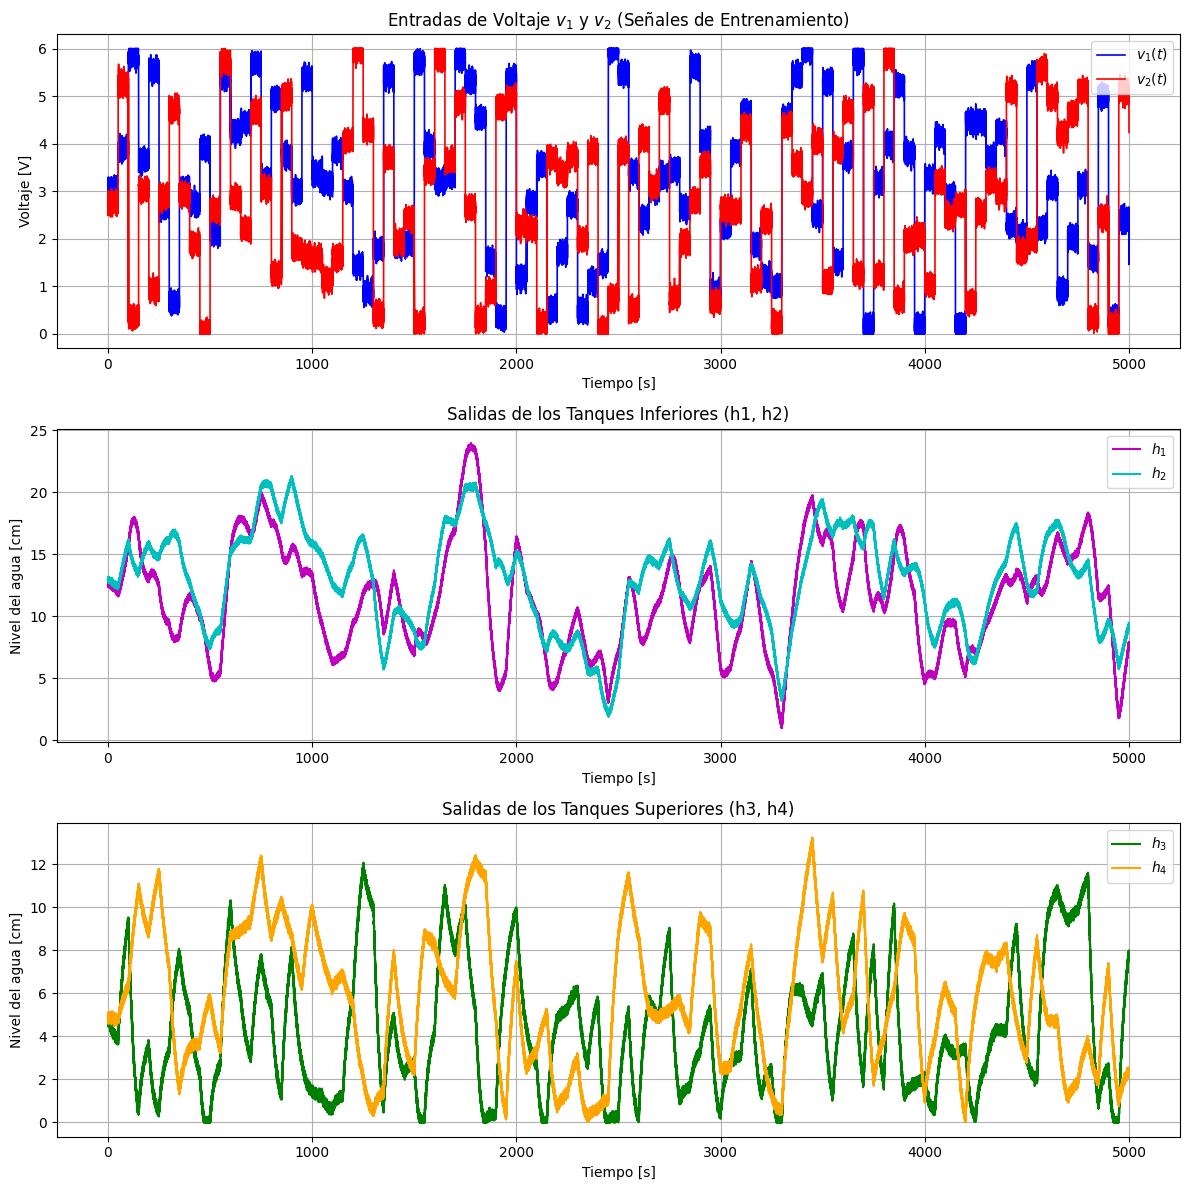

In [8]:
# Creación del lienzo para la visualización de señales de entrenamiento
plt.figure(figsize=(12, 12))

# Visualización de los voltajes de entrada aplicados a las bombas
plt.subplot(3, 1, 1)
plt.plot(t_full, u_full[:, 0], 'b', linewidth=1.2, label='$v_1(t)$')
plt.plot(t_full, u_full[:, 1], 'r', linewidth=1.2, label='$v_2(t)$')
plt.xlabel('Tiempo [s]')
plt.ylabel('Voltaje [V]')
plt.title('Entradas de Voltaje $v_1$ y $v_2$ (Señales de Entrenamiento)')
plt.legend(loc='upper right')
plt.grid(True)

# Visualización de la respuesta dinámica de los tanques inferiores
plt.subplot(3, 1, 2)
plt.plot(t_full, h1_full, 'm', linewidth=1.5, label='$h_1$')
plt.plot(t_full, h2_full, 'c', linewidth=1.5, label='$h_2$')
plt.xlabel('Tiempo [s]')
plt.ylabel('Nivel del agua [cm]')
plt.title('Salidas de los Tanques Inferiores (h1, h2)')
plt.legend(loc='upper right')
plt.grid(True)

# Visualización de la respuesta dinámica de los tanques superiores
plt.subplot(3, 1, 3)
plt.plot(t_full, h3_full, 'g', linewidth=1.5, label='$h_3$')
plt.plot(t_full, h4_full, 'orange', linewidth=1.5, label='$h_4$')
plt.xlabel('Tiempo [s]')
plt.ylabel('Nivel del agua [cm]')
plt.title('Salidas de los Tanques Superiores (h3, h4)')
plt.legend(loc='upper right')
plt.grid(True)

# Ajuste de disposición y despliegue de las subgráficas
plt.tight_layout()
plt.show()

In [9]:
from scipy.optimize import fsolve

# 1. Definir el voltaje de operación (promedio de la señal PRBS)
v1_op = 3.15
v2_op = 3.15
u_op = np.array([v1_op, v2_op])

h_op = np.array([12.6, 13.0, 4.8, 4.9])

print(f"Punto de operación de Voltaje: v1={v1_op:.2f}V, v2={v2_op:.2f}V")
print(f"Niveles de equilibrio calculados: h1={h_op[0]:.2f}, h2={h_op[1]:.2f}, h3={h_op[2]:.2f}, h4={h_op[3]:.2f} [cm]")

Punto de operación de Voltaje: v1=3.15V, v2=3.15V
Niveles de equilibrio calculados: h1=12.60, h2=13.00, h3=4.80, h4=4.90 [cm]


In [10]:
# Definición de constantes auxiliares para simplificar el cálculo de las matrices
# Tiempos de descarga característicos (Ti = Ai/ai * sqrt(2*h_op/g))
T1 = (A1 / a1) * np.sqrt(2 * h_op[0] / g)
T2 = (A2 / a2) * np.sqrt(2 * h_op[1] / g)
T3 = (A3 / a3) * np.sqrt(2 * h_op[2] / g)
T4 = (A4 / a4) * np.sqrt(2 * h_op[3] / g)

# --- Matriz A (4x4) ---
# Derivadas de las ecuaciones de estado respecto a h1, h2, h3, h4
A = np.array([
    [-1/T1,     0,      (A3/(A1*T3)),      0],
    [0,      -1/T2,          0,       (A4/(A2*T4))],
    [0,         0,        -1/T3,           0],
    [0,         0,           0,        -1/T4]
])

# --- Matriz B (4x2) ---
# Derivadas de las ecuaciones de estado respecto a v1 y v2
B = np.array([
    [(gamma1 * k1 / A1),       0],
    [0,                 (gamma2 * k2 / A2)],
    [0,           ((1 - gamma2) * k2 / A3)],
    [((1 - gamma1) * k1 / A4),       0]
])

# --- Matriz C (Identidad si medimos todos los niveles) ---
C = np.eye(4)

# --- Matriz D (Cero, no hay transmisión directa) ---
D = np.zeros((4, 2))

print("Matriz A (Dinámica de estados):")
print(np.round(A, 4))
print("\nMatriz B (Efecto de las bombas):")
print(np.round(B, 4))

Matriz A (Dinámica de estados):
[[-0.0158  0.      0.0256  0.    ]
 [ 0.     -0.0109  0.      0.0178]
 [ 0.      0.     -0.0256  0.    ]
 [ 0.      0.      0.     -0.0178]]

Matriz B (Efecto de las bombas):
[[0.0482 0.    ]
 [0.     0.035 ]
 [0.     0.0775]
 [0.0559 0.    ]]


In [11]:
# 1. Definición de la función de la EDO linealizada
def linear_ode_system(t, delta_h, u_func, A, B, u_op):
    # Obtener entrada actual y calcular la desviación (delta_u)
    u_t = u_func(t)
    delta_u = u_t - u_op

    # Ecuación de estado lineal: d(delta_h)/dt = A * delta_h + B * delta_u
    ddelta_h_dt = A @ delta_h + B @ delta_u

    return ddelta_h_dt

# 2. Condiciones iniciales para el modelo lineal (desviación respecto al equilibrio)
delta_h0 = h0 - h_op

# 3. Integración del modelo lineal
sol_linear = solve_ivp(
    fun=lambda tt, hh: linear_ode_system(tt, hh, u_fun, A, B, u_op),
    t_span=[t[0], t[-1]],
    y0=delta_h0,
    method='RK45',
    t_eval=t
)

# 4. Reconstrucción de los niveles totales (h_lineal = h_op + delta_h)
h_linear_sim = sol_linear.y.T + h_op

In [12]:
# --- CÁLCULO DE MÉTRICAS (RMSE y VAF) ---
def calculate_metrics(real, pred):
    rmse = np.sqrt(np.mean((real - pred)**2))
    vaf = max(0, (1 - np.var(real - pred) / np.var(real)) * 100)
    return rmse, vaf

# Calculamos métricas para cada tanque
rmse1, vaf1 = calculate_metrics(h1_full, h_linear_sim[:, 0])
rmse2, vaf2 = calculate_metrics(h2_full, h_linear_sim[:, 1])
rmse3, vaf3 = calculate_metrics(h3_full, h_linear_sim[:, 2])
rmse4, vaf4 = calculate_metrics(h4_full, h_linear_sim[:, 3])

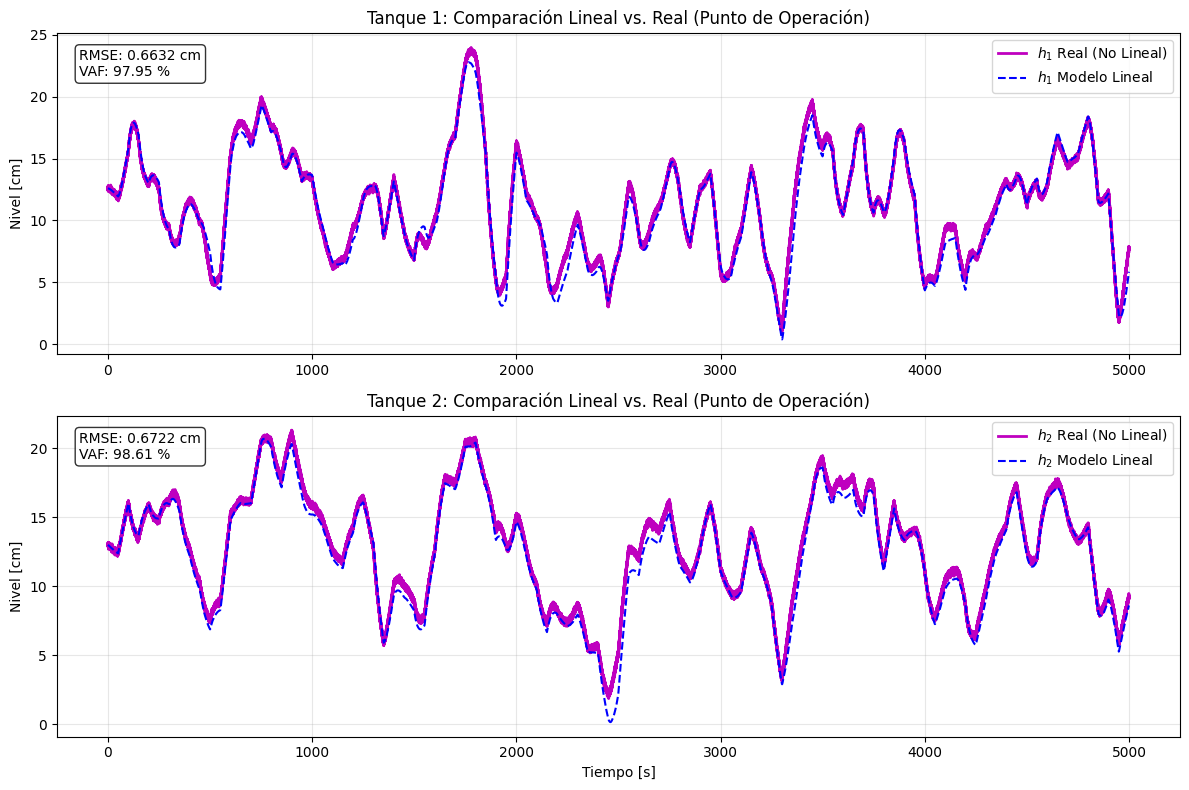

In [13]:
# --- PIEZA NO. 1: TANQUES INFERIORES ---
plt.figure(figsize=(12, 8))

# Tanque 1
plt.subplot(2, 1, 1)
plt.plot(t_full, h1_full, 'm', linewidth=2, label='$h_1$ Real (No Lineal)')
plt.plot(t_full, h_linear_sim[:, 0], 'b--', linewidth=1.5, label='$h_1$ Modelo Lineal')
plt.ylabel('Nivel [cm]')
plt.title('Tanque 1: Comparación Lineal vs. Real (Punto de Operación)')
textstr1 = '\n'.join((f'RMSE: {rmse1:.4f} cm', f'VAF: {vaf1:.2f} %'))
plt.gca().text(0.02, 0.95, textstr1, transform=plt.gca().transAxes, fontsize=10,
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

# Tanque 2
plt.subplot(2, 1, 2)
plt.plot(t_full, h2_full, 'm', linewidth=2, label='$h_2$ Real (No Lineal)')
plt.plot(t_full, h_linear_sim[:, 1], 'b--', linewidth=1.5, label='$h_2$ Modelo Lineal')
plt.ylabel('Nivel [cm]')
plt.xlabel('Tiempo [s]')
plt.title('Tanque 2: Comparación Lineal vs. Real (Punto de Operación)')
textstr2 = '\n'.join((f'RMSE: {rmse2:.4f} cm', f'VAF: {vaf2:.2f} %'))
plt.gca().text(0.02, 0.95, textstr2, transform=plt.gca().transAxes, fontsize=10,
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [14]:
import pandas as pd

# 1. Estructuración de los datos de Linealización Clásica (Tanques Inferiores)
data_linear_inf = {
    'Tiempo [s]': t_full.flatten(),
    # Nivel Real (referencia)
    'h1_Real [cm]': h1_full.flatten(),
    'h2_Real [cm]': h2_full.flatten(),
    # Predicción del Modelo Lineal (Jacobianos / Punto de Operación)
    # Usamos el sufijo "Classical" para que coincida con la leyenda 'Classical Linear'
    'h1_Classical [cm]': h_linear_sim[:, 0].flatten(),
    'h2_Classical [cm]': h_linear_sim[:, 1].flatten()
}

# 2. Creación del DataFrame
df_linear_inf = pd.DataFrame(data_linear_inf)

# 3. Exportación a CSV
nombre_linear_inf_csv = "comparacion_linealizacion_tanques_inferiores.csv"
df_linear_inf.to_csv(nombre_linear_inf_csv, index=False, sep=',', encoding='utf-8')

print(f"✅ Archivo de Linealización (Inferiores) guardado como: {nombre_linear_inf_csv}")

✅ Archivo de Linealización (Inferiores) guardado como: comparacion_linealizacion_tanques_inferiores.csv


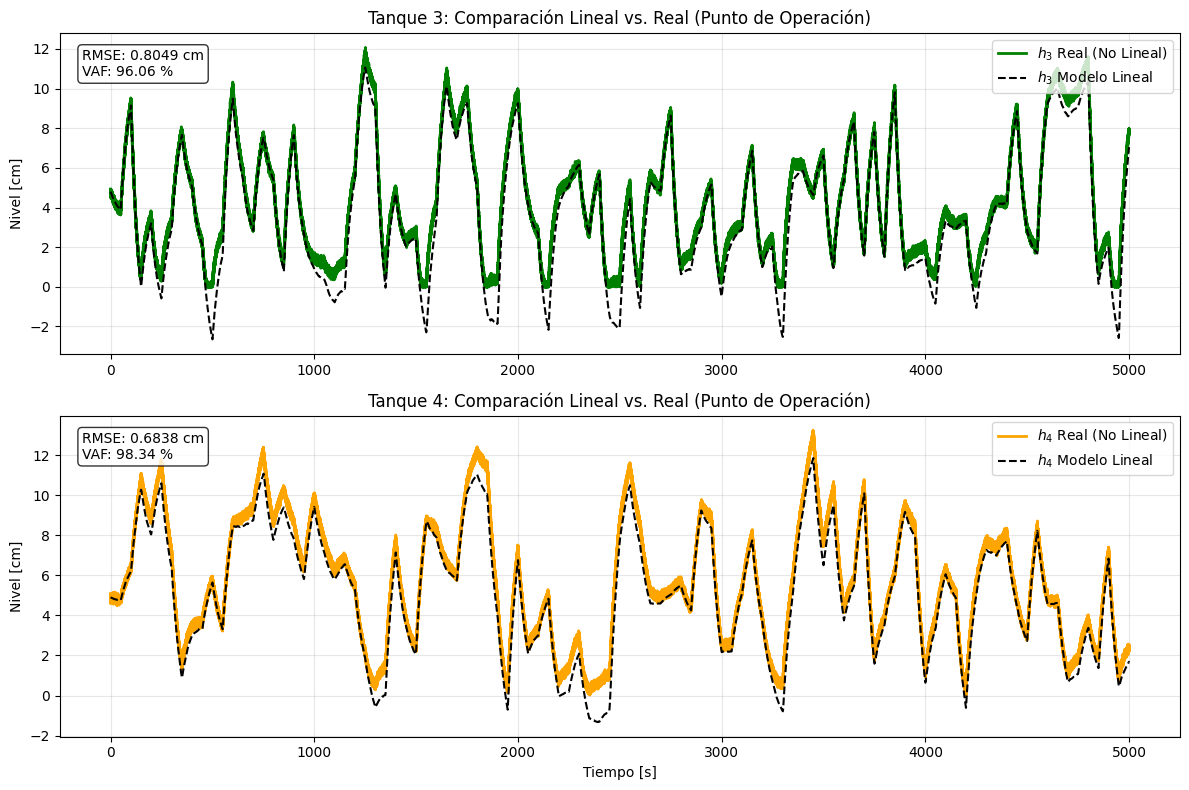

In [15]:
# --- PIEZA NO. 2: TANQUES SUPERIORES ---
plt.figure(figsize=(12, 8))

# Tanque 3
plt.subplot(2, 1, 1)
plt.plot(t_full, h3_full, 'g', linewidth=2, label='$h_3$ Real (No Lineal)')
plt.plot(t_full, h_linear_sim[:, 2], 'k--', linewidth=1.5, label='$h_3$ Modelo Lineal')
plt.ylabel('Nivel [cm]')
plt.title('Tanque 3: Comparación Lineal vs. Real (Punto de Operación)')
textstr3 = '\n'.join((f'RMSE: {rmse3:.4f} cm', f'VAF: {vaf3:.2f} %'))
plt.gca().text(0.02, 0.95, textstr3, transform=plt.gca().transAxes, fontsize=10,
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

# Tanque 4
plt.subplot(2, 1, 2)
plt.plot(t_full, h4_full, 'orange', linewidth=2, label='$h_4$ Real (No Lineal)')
plt.plot(t_full, h_linear_sim[:, 3], 'k--', linewidth=1.5, label='$h_4$ Modelo Lineal')
plt.ylabel('Nivel [cm]')
plt.xlabel('Tiempo [s]')
plt.title('Tanque 4: Comparación Lineal vs. Real (Punto de Operación)')
textstr4 = '\n'.join((f'RMSE: {rmse4:.4f} cm', f'VAF: {vaf4:.2f} %'))
plt.gca().text(0.02, 0.95, textstr4, transform=plt.gca().transAxes, fontsize=10,
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [16]:
import pandas as pd

# 1. Estructuración de los datos de Linealización Clásica (Tanques Superiores)
data_linear_sup = {
    'Tiempo [s]': t_full.flatten(),
    # Niveles Reales (Referencia física)
    'h3_Real [cm]': h3_full.flatten(),
    'h4_Real [cm]': h4_full.flatten(),
    # Predicción del Modelo Lineal Clásico
    # Usamos "Classical" para que el script IEEE lo reconozca según el label 'Classical Linear'
    'h3_Classical [cm]': h_linear_sim[:, 2].flatten(),
    'h4_Classical [cm]': h_linear_sim[:, 3].flatten()
}

# 2. Creación del DataFrame
df_linear_sup = pd.DataFrame(data_linear_sup)

# 3. Exportación a CSV
nombre_linear_sup_csv = "comparacion_linealizacion_tanques_superiores.csv"
df_linear_sup.to_csv(nombre_linear_sup_csv, index=False, sep=',', encoding='utf-8')

print(f"✅ Archivo de Linealización (Superiores) guardado como: {nombre_linear_sup_csv}")

✅ Archivo de Linealización (Superiores) guardado como: comparacion_linealizacion_tanques_superiores.csv
